# **EfficientNet Pre-trained Binary Model**

In this notebook, we train the final EfficientNet Pre-trained Binary Model and make predictions on the test set.<br>
Eventhough the upsample model with binary crossentropy loss function, no regularization and no dropout in `03_efficent_net_pretrained_upsample.ipynb` yielded the best precision results, it demonstrated a lot of underfit.<br>
Therefore, we select as the final model for predictions the one with binary crossentropy loss function, no regularization and no dropout from `02_efficient_net_pretrained_transformations.ipynb` to make the final predictions.

## Libraries

In [1]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

In [2]:
# Libraries
import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, precision_score, recall_score

from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.metrics import AUC
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from deep.constants import ROOT, METADATA_FILE, SEEDS, METADATA_DIR, INPUT_DIR, MODEL_IMAGE_SIZE, BATCH_SIZE
from deep.modelling.model_specifications import efficient_net_extended
from deep.modelling.pipiline_utils import split_data
from deep.preprocess.album_augmenter import compute_effective_class_weights
from deep.modelling.metric_utils import get_fitted_model_metrics, plot_confusion_matrix, plot_metrics

2025-05-01 09:05:29.527688: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-01 09:05:29.540121: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-01 09:05:29.554334: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-01 09:05:29.559070: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-01 09:05:29.569556: I tensorflow/core/platform/cpu_feature_guar

In [3]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [4]:
# Load the metadata
data = pd.read_csv(METADATA_FILE)

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

## Data Preprocessing

In [5]:
# Define seeds and path
binary_baseline_path = f"{ROOT}/models/binary_scores.json"

### Clean Images

In [ ]:
# Create transformed images
notebook_path = f'"{ROOT}/notebooks/preprocess_routine/cleaner_routine.ipynb"'
%run $notebook_path

### Resize Images

In [6]:
# Resize images
notebook_path = f'"{ROOT}/notebooks/preprocess_routine/resize_routine.ipynb"'
%run $notebook_path

2025-05-01 09:05:34.989199: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-05-01 09:05:34.989226: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:135] retrieving CUDA diagnostic information for host: shadybea
2025-05-01 09:05:34.989232: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:142] hostname: shadybea
2025-05-01 09:05:34.989334: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:166] libcuda reported version is: 550.120.0
2025-05-01 09:05:34.989351: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] kernel reported version is: 550.120.0
2025-05-01 09:05:34.989355: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:249] kernel version seems to match DSO: 550.120.0
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 8

## Data Modelling

In [ ]:
# Defining the training and test sets
train_df, test_df = split_data(data, 'is_animal', SEEDS[0], val_size=0, save_split=False)

In [9]:
# Changing target to string
train_df['is_animal'] = train_df['is_animal'].astype(str)
test_df['is_animal'] = test_df['is_animal'].astype(str)

In [10]:
train_datagen = ImageDataGenerator(
    rotation_range=90,
    shear_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    channel_shift_range=30.0,
    zoom_range=(0.8, 1.2),
    fill_mode='nearest',
    rescale=1./255
)
test_datagen = ImageDataGenerator(rescale=1./255)

# Train generator
binary_train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=INPUT_DIR,
    x_col='file_path',
    y_col='is_animal',
    target_size=MODEL_IMAGE_SIZE['efficientnetb4'],
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEEDS[0],
    shuffle=True
)

# Test generator
binary_test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=INPUT_DIR,
    x_col='file_path',
    y_col='is_animal',
    target_size=MODEL_IMAGE_SIZE['efficientnetb4'],
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 9586 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


In [11]:
# Compute class weights
class_weights = compute_effective_class_weights(train_df, 'is_animal')

In [ ]:
# Defining the model
binary_model, _ = efficient_net_extended(regularizer=False, dropout=False, task_type='binary')

# Compiling the model
binary_model.compile(
    optimizer=RMSprop(learning_rate=0.001)
    ,loss='binary_crossentropy'
    ,metrics=['accuracy', AUC(), 'precision', 'recall']
)

# Fit the model
fitted_binary = binary_model.fit(
    binary_train_generator
    ,epochs=20
    ,steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE))
    ,class_weight=class_weights
    ,callbacks=[
        ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
    ]
    ,verbose=1
)

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1245s 4s/step - accuracy: 0.9220 - auc: 0.5475 - loss: 0.2859 - precision: 0.9278 - recall: 0.9929 - learning_rate: 0.0010
Epoch 2/20


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,auc,loss,precision,recall,learning_rate.
  callback.on_epoch_end(epoch, logs)


300/300 ━━━━━━━━━━━━━━━━━━━━ 1239s 4s/step - accuracy: 0.9276 - auc: 0.5319 - loss: 0.2624 - precision: 0.9276 - recall: 1.0000 - learning_rate: 0.0010
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1208s 4s/step - accuracy: 0.9275 - auc: 0.5484 - loss: 0.2617 - precision: 0.9275 - recall: 1.0000 - learning_rate: 0.0010
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1195s 4s/step - accuracy: 0.9229 - auc: 0.5525 - loss: 0.2724 - precision: 0.9229 - recall: 1.0000 - learning_rate: 0.0010
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1250s 4s/step - accuracy: 0.9297 - auc: 0.5895 - loss: 0.2512 - precision: 0.9297 - recall: 1.0000 - learning_rate: 0.0010
Epoch 6/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1265s 4s/step - accuracy: 0.9315 - auc: 0.5385 - loss: 0.2525 - precision: 0.9315 - recall: 1.0000 - learning_rate: 0.0010
Epoch 7/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 1244s 4s/step - accuracy: 0.9293 - auc: 0.6016 - loss: 0.2512 - precision: 0.9293 - recall: 1.0000 - learning_rate: 0.0010
Epoch 8/20
300/300 ━━━━━━━━━━━━━━

In [13]:
get_fitted_model_metrics(model=fitted_binary, is_final=True)

Train Loss: 0.24985907971858978
Train Precision:0.9293761849403381


In [ ]:
# Get the model AUC

history = fitted_binary.history
# Get best epoch metrics
best_epoch = np.argmin(history['loss'])

print(f"Model AUC: {history['auc'][best_epoch]}")

Model AUC: 0.6212670803070068


In [18]:
# Make predictions
predictions = binary_model.predict(
    binary_test_generator
    ,steps=len(binary_test_generator)
    ,verbose=1
)

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


75/75 ━━━━━━━━━━━━━━━━━━━━ 297s 4s/step


In [19]:
# Get the true labels
y_true = binary_test_generator.labels

# Convert predictions to class labels
y_pred = (predictions > 0.5).astype(int).flatten()

# Calculate metrics
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")

Accuracy: 0.9295
Precision: 0.9295
Recall: 1.0000


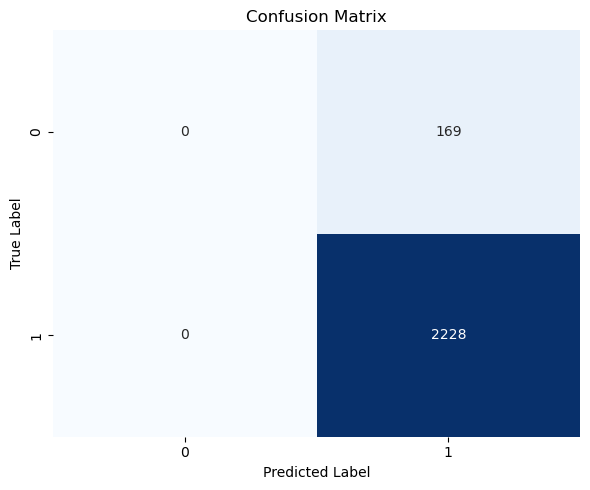

In [23]:
# Plot confusion matrix
plot_confusion_matrix(y_true, y_pred, sorted(np.unique(np.concatenate((y_true, y_pred)))))

Despite good accuracy and precision on the train and test sets, the model was unable to learn the 'no animal' class, therefore it only predict the test set images as 'animal'.